In [52]:
# Algerian_dataset_cleaned.csv

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [54]:
df= pd.read_csv("/content/Algerian_forest_fires_cleaned_dataset.csv")

In [55]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [56]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [57]:
df.drop(['day','month','year'],axis=1,inplace=True)

In [58]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [59]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


In [60]:
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

In [61]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


In [62]:
# independet and depenent features
X=df.drop('FWI',axis=1)
y=df['FWI']

In [63]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [64]:
#feature selection based on corr
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

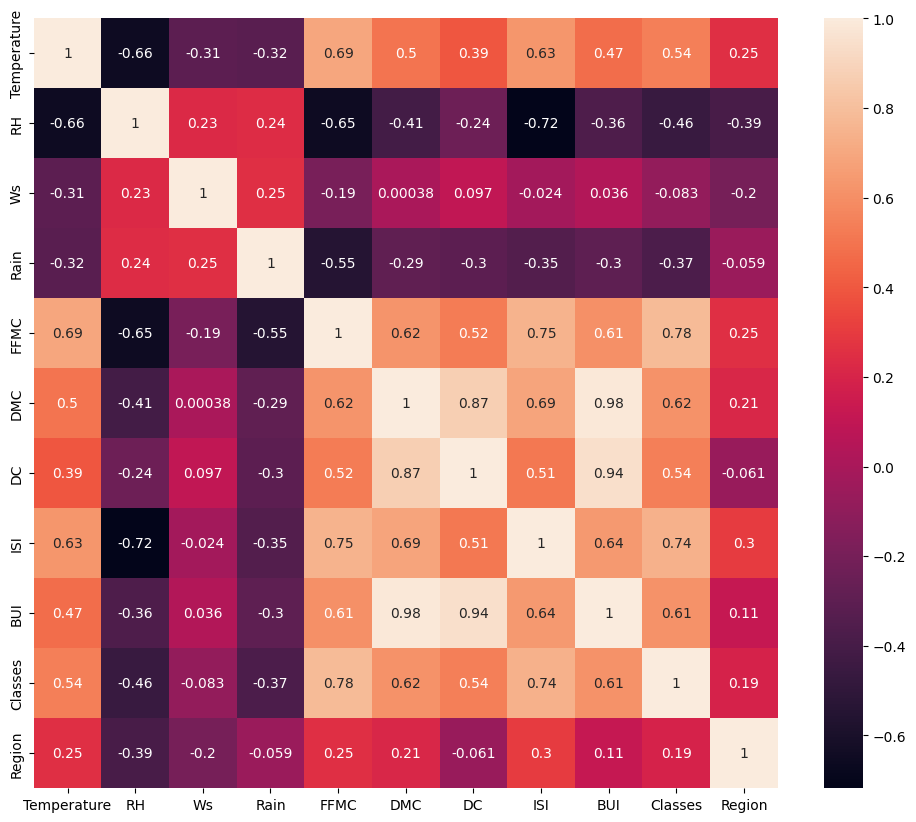

In [65]:
#check for multicolinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [66]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [67]:
corr_features=correlation(X_train,0.80)
corr_features

{'BUI', 'DC'}

In [68]:
#droop features when correlation is more than 0.80
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)


FEATURE SCALING

In [69]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train_scale=sc.fit_transform(X_train)
X_test_scale=sc.transform(X_test)

Text(0.5, 1.0, 'X_train After Scaling')

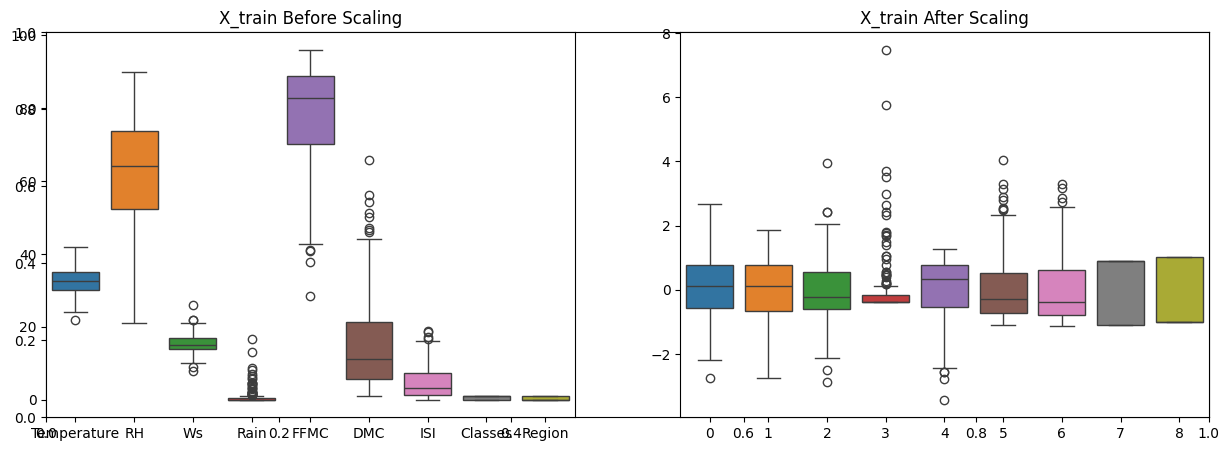

In [70]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scale)
plt.title('X_train After Scaling')

Linear Regression Model

Mean Absolute Error: 0.5468236465249986
R2 Score: 0.9847657384266951


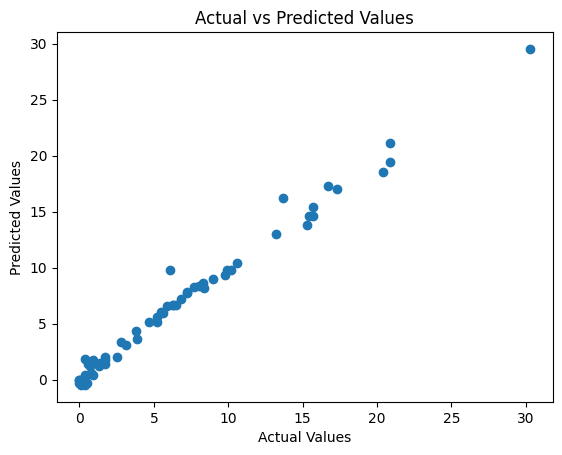

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lr=LinearRegression()
lr.fit(X_train_scale,y_train)
y_pred=lr.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mae)
score= r2_score(y_test,y_pred)
print("R2 Score:",score)
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

LASSO REGRESSION

Mean Absolute Error: 1.133175994914409
R2 Score: 0.9492020263112388


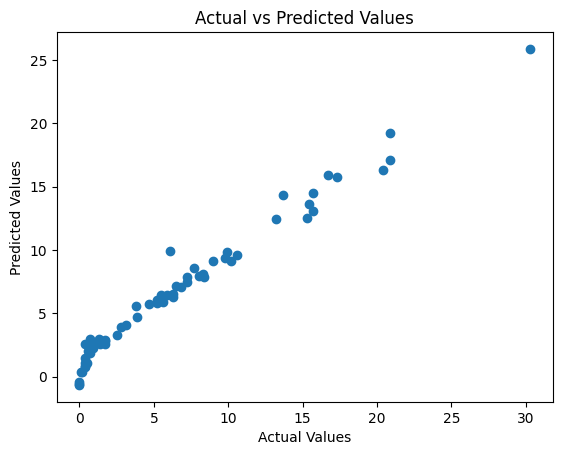

In [76]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
lasso= Lasso()
lasso.fit(X_train_scale,y_train)
y_pred=lasso.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mae)
score= r2_score(y_test,y_pred)
print("R2 Score:",score)
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [ ]:
from sklearn.linear_model import LassoCV
LassoCV= LassoCV()
LassoCV.fit(X_train_scale,y_train)

RIDGE REGRESSION

Mean Absolute Error: 0.5642305340105692
R2 Score: 0.9842993364555513


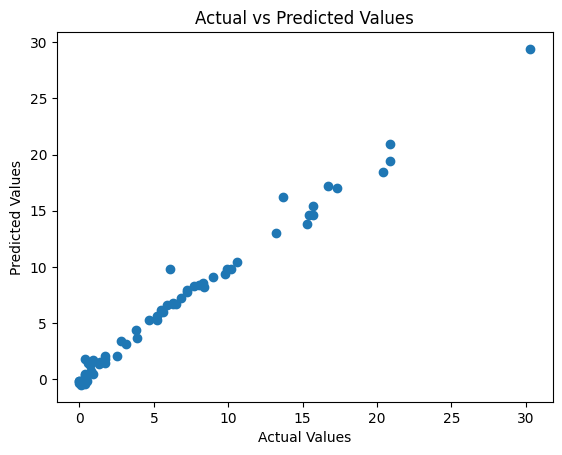

In [77]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
ridge= Ridge()
ridge.fit(X_train_scale,y_train)
y_pred=ridge.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mae)
score= r2_score(y_test,y_pred)
print("R2 Score:",score)
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

ELASTIC NET

Mean Absolute Error: 1.8822353634896005
R2 Score: 0.8753460589519703


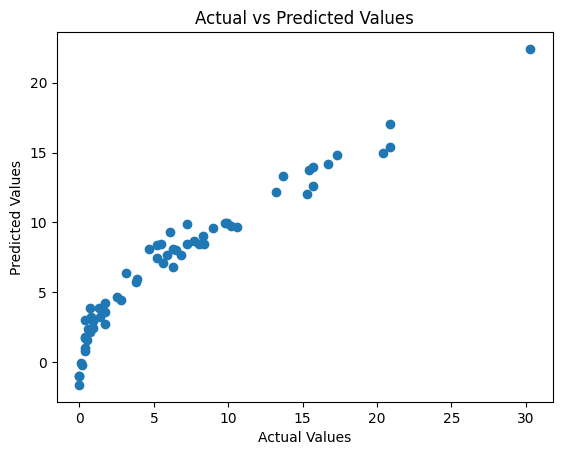

In [78]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
elastic= ElasticNet()
elastic.fit(X_train_scale,y_train)
y_pred=elastic.predict(X_test_scale)
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mae)
score= r2_score(y_test,y_pred)
print("R2 Score:",score)
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()